# Phase 6 — Model Evaluation & Comparison (Fixed Version)

This notebook evaluates:

- Logistic Regression
- Decision Tree
- Random Forest

It automatically searches for the cleaned dataset in common project locations, including:

```text
dataset/proces/clean_employee_attrition.csv
data/processed/clean_employee_attrition.csv
```

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_COLUMN = "Attrition"

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Find the Project Root and Dataset Automatically

In [8]:
from pathlib import Path

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "clean_employee_attrition.csv"
)

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Current directory:", CURRENT_DIR.resolve())
print("Project root:", PROJECT_ROOT.resolve())
print("Dataset:", DATA_PATH.resolve())
print("Models directory:", MODELS_DIR.resolve())

Current directory: C:\Users\Nasteho Abdi\employee-attrition-prediction\notebooks
Project root: C:\Users\Nasteho Abdi\employee-attrition-prediction
Dataset: C:\Users\Nasteho Abdi\employee-attrition-prediction\data\processed\clean_employee_attrition.csv
Models directory: C:\Users\Nasteho Abdi\employee-attrition-prediction\models


## 2. Configure Model and Report Paths

In [9]:
MODEL_PATHS = {
    "Logistic Regression": MODELS_DIR / "logistic_regression.joblib",
    "Decision Tree": MODELS_DIR / "decision_tree.joblib",
    "Random Forest": MODELS_DIR / "random_forest.joblib",
}

METRICS_PATH = REPORTS_DIR / "model_comparison.csv"
REPORT_PATH = REPORTS_DIR / "classification_reports.json"
BEST_MODEL_INFO_PATH = REPORTS_DIR / "best_model_info.json"
BEST_MODEL_PATH = MODELS_DIR / "best_model.joblib"

print("Models directory:", MODELS_DIR.resolve())
print("Reports directory:", REPORTS_DIR.resolve())

Models directory: C:\Users\Nasteho Abdi\employee-attrition-prediction\models
Reports directory: C:\Users\Nasteho Abdi\employee-attrition-prediction\reports


## 3. Load and Validate the Dataset

In [10]:
df = pd.read_csv(DATA_PATH)

if df.empty:
    raise ValueError("The cleaned dataset is empty.")

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

if df[TARGET_COLUMN].isnull().any():
    raise ValueError("The target column contains missing values.")

unexpected_values = set(df[TARGET_COLUMN].unique()) - {0, 1}

if unexpected_values:
    raise ValueError(
        f"Unexpected target values found: {unexpected_values}"
    )

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


## 4. Recreate the Same Train/Test Split

In [11]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 1176
Test rows: 294


## 5. Load the Trained Models

In [12]:
import joblib

MODEL_PATHS = {
    "Logistic Regression": (
        MODELS_DIR / "logistic_regression.joblib"
    ),
    "Decision Tree": (
        MODELS_DIR / "decision_tree.joblib"
    ),
    "Random Forest": (
        MODELS_DIR / "random_forest.joblib"
    ),
}

models = {}

for model_name, model_path in MODEL_PATHS.items():
    if not model_path.exists():
        raise FileNotFoundError(
            f"{model_name} lama helin: {model_path.resolve()}"
        )

    models[model_name] = joblib.load(model_path)
    print(f"Loaded: {model_name}")

Loaded: Logistic Regression
Loaded: Decision Tree
Loaded: Random Forest


## 6. Evaluate All Models

In [13]:
evaluation_rows = []
classification_reports = {}
predictions = {}
probabilities = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    if hasattr(model, "predict_proba"):
        y_probability = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_probability = model.decision_function(X_test)
    else:
        y_probability = None

    probabilities[model_name] = y_probability

    evaluation_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "ROC-AUC": (
            roc_auc_score(y_test, y_probability)
            if y_probability is not None
            else np.nan
        ),
    })

    classification_reports[model_name] = (
        classification_report(
            y_test,
            y_pred,
            target_names=["Stay", "Leave"],
            output_dict=True,
            zero_division=0,
        )
    )

metrics_df = pd.DataFrame(evaluation_rows)

metrics_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8605,0.6154,0.3404,0.4384,0.8115
1,Decision Tree,0.7653,0.3103,0.3830,0.3429,0.6105
2,Random Forest,0.8503,0.6364,0.1489,0.2414,0.8037


## 7. Classification Reports

In [14]:
for model_name, report in classification_reports.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    display(
        pd.DataFrame(report)
        .transpose()
        .round(4)
    )

Logistic Regression


,precision,recall,f1-score,support
Stay,0.8843,0.9595,0.9204,247.0000
Leave,0.6154,0.3404,0.4384,47.0000
accuracy,0.8605,0.8605,0.8605,0.8605
macro avg,0.7499,0.6500,0.6794,294.0000
weighted avg,0.8413,0.8605,0.8433,294.0000


Decision Tree


,precision,recall,f1-score,support
Stay,0.8771,0.8381,0.8571,247.0000
Leave,0.3103,0.3830,0.3429,47.0000
accuracy,0.7653,0.7653,0.7653,0.7653
macro avg,0.5937,0.6105,0.6000,294.0000
weighted avg,0.7865,0.7653,0.7749,294.0000


Random Forest


,precision,recall,f1-score,support
Stay,0.8587,0.9838,0.9170,247.0000
Leave,0.6364,0.1489,0.2414,47.0000
accuracy,0.8503,0.8503,0.8503,0.8503
macro avg,0.7475,0.5664,0.5792,294.0000
weighted avg,0.8231,0.8503,0.8090,294.0000


## 8. Confusion Matrices

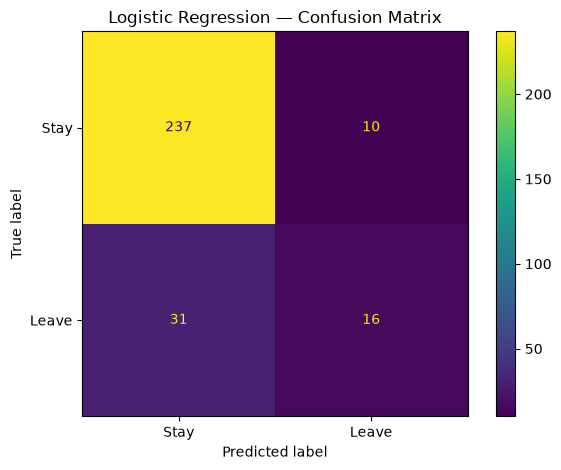

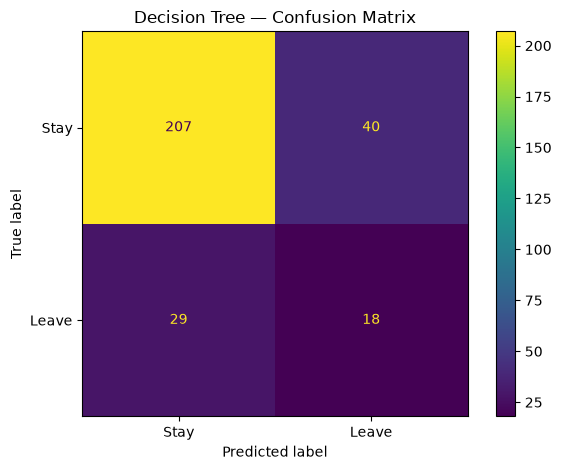

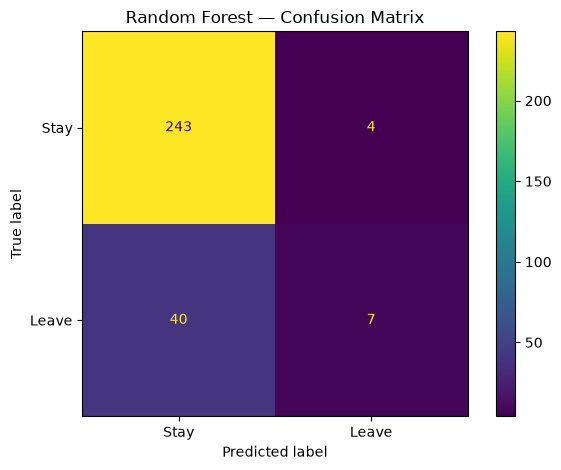

In [15]:
for model_name, y_pred in predictions.items():
    matrix = confusion_matrix(y_test, y_pred)

    display_object = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Stay", "Leave"],
    )

    display_object.plot(values_format="d")
    plt.title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()

    filename = (
        model_name.lower()
        .replace(" ", "_")
        + "_confusion_matrix.png"
    )

    plt.savefig(
        FIGURES_DIR / filename,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

## 9. ROC Curves

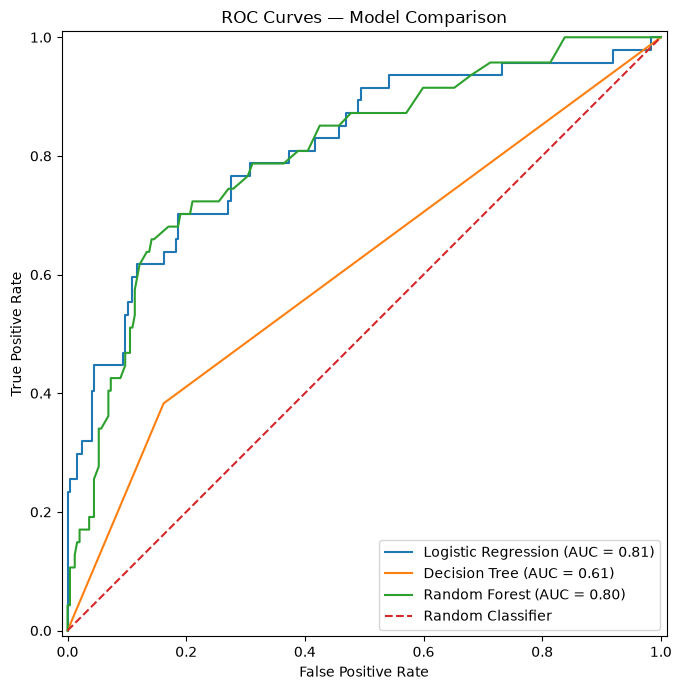

In [16]:
plt.figure(figsize=(9, 7))

for model_name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name,
        ax=plt.gca(),
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier",
)

plt.title("ROC Curves — Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_roc_curves.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 10. Metrics Comparison Chart

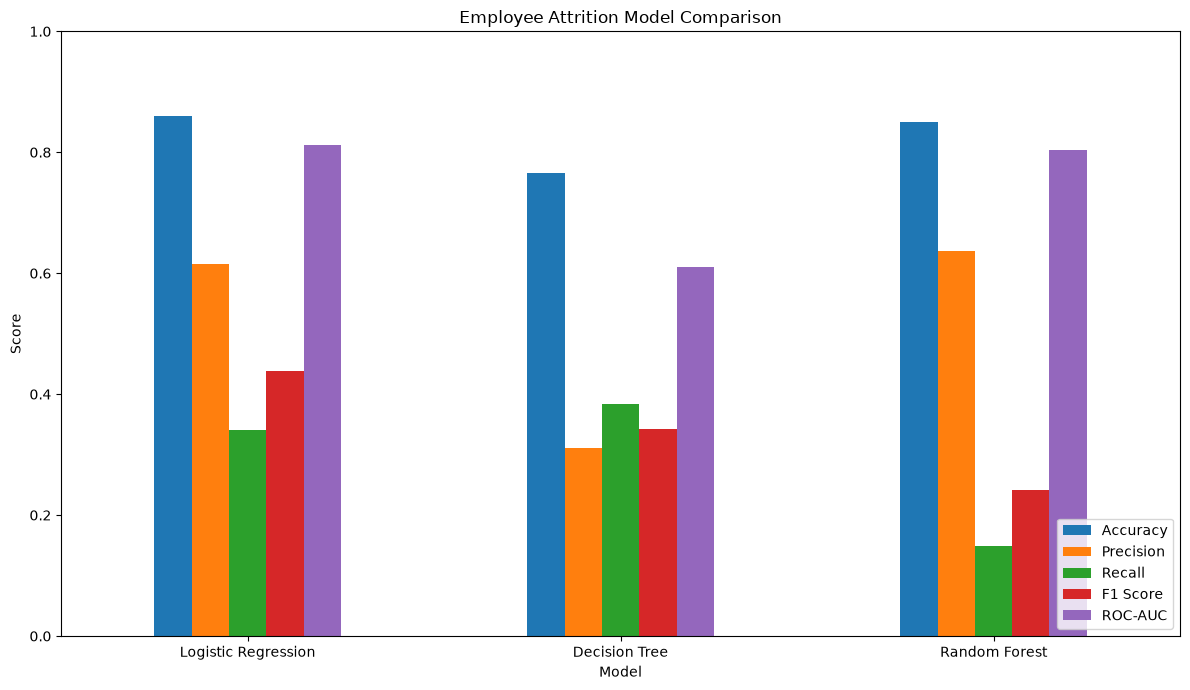

In [17]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
]

metrics_df.set_index("Model")[metric_columns].plot(
    kind="bar",
    figsize=(12, 7),
)

plt.title("Employee Attrition Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_metrics_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 11. Rank and Select the Best Model

In [18]:
ranking_df = metrics_df.sort_values(
    by=["F1 Score", "ROC-AUC", "Recall"],
    ascending=False,
).reset_index(drop=True)

ranking_df["Rank"] = range(
    1,
    len(ranking_df) + 1,
)

ranking_df[
    [
        "Rank",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
    ]
].round(4)

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,Logistic Regression,0.8605,0.6154,0.3404,0.4384,0.8115
1,2,Decision Tree,0.7653,0.3103,0.3830,0.3429,0.6105
2,3,Random Forest,0.8503,0.6364,0.1489,0.2414,0.8037


In [19]:
best_model_name = ranking_df.loc[0, "Model"]
best_model = models[best_model_name]

print("Selected best model:", best_model_name)

Selected best model: Logistic Regression


## 12. Save the Best Model and Reports

In [20]:
joblib.dump(
    best_model,
    BEST_MODEL_PATH,
)

metrics_df.to_csv(
    METRICS_PATH,
    index=False,
)

with REPORT_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        classification_reports,
        file,
        indent=4,
    )

best_row = ranking_df.iloc[0]

best_model_info = {
    "best_model": best_model_name,
    "selection_metric": "F1 Score",
    "accuracy": float(best_row["Accuracy"]),
    "precision": float(best_row["Precision"]),
    "recall": float(best_row["Recall"]),
    "f1_score": float(best_row["F1 Score"]),
    "roc_auc": float(best_row["ROC-AUC"]),
    "model_file": BEST_MODEL_PATH.name,
    "dataset_file": str(DATA_PATH.resolve()),
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
}

with BEST_MODEL_INFO_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        best_model_info,
        file,
        indent=4,
    )

print("Best model saved to:", BEST_MODEL_PATH.resolve())
print("Metrics saved to:", METRICS_PATH.resolve())
print("Reports saved successfully.")

Best model saved to: C:\Users\Nasteho Abdi\employee-attrition-prediction\models\best_model.joblib
Metrics saved to: C:\Users\Nasteho Abdi\employee-attrition-prediction\reports\model_comparison.csv
Reports saved successfully.


## 13. Verify the Saved Model

In [21]:
loaded_best_model = joblib.load(
    BEST_MODEL_PATH
)

sample_predictions = loaded_best_model.predict(
    X_test.head(5)
)

print("Saved model loaded successfully.")
print("Sample predictions:", sample_predictions)

Saved model loaded successfully.
Sample predictions: [0 0 0 0 0]


# Phase 6 Completed

Generated outputs:

```text
models/
└── best_model.joblib

reports/
├── model_comparison.csv
├── classification_reports.json
├── best_model_info.json
└── figures/
    ├── logistic_regression_confusion_matrix.png
    ├── decision_tree_confusion_matrix.png
    ├── random_forest_confusion_matrix.png
    ├── model_roc_curves.png
    └── model_metrics_comparison.png
```